In [1]:
import pandas as pd

df = pd.read_csv("../data/q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_date     1200 non-null   str  
 1   store_id             1200 non-null   int64
 2   store_size           1200 non-null   str  
 3   location_type        1200 non-null   str  
 4   promotion_type       1200 non-null   str  
 5   is_weekend           1200 non-null   int64
 6   is_festival          1200 non-null   int64
 7   competition_density  1200 non-null   int64
 8   items_sold           1200 non-null   int64
dtypes: int64(5), str(4)
memory usage: 84.5 KB


Index(['transaction_date', 'store_id', 'store_size', 'location_type',
       'promotion_type', 'is_weekend', 'is_festival', 'competition_density',
       'items_sold'],
      dtype='str')

In [4]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New temporal features were extracted from the transaction_date column to capture time-based patterns:

- year: Captures yearly trends
- month: Captures seasonality
- day_of_week: Captures weekly behavior
- is_month_end: Indicates end-of-month purchasing patterns (1 if day >= 25)

These features help the model learn temporal trends in sales.

In [5]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(columns=['items_sold'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold'])
y_test = test_df['items_sold']

In [6]:
X_train = X_train.drop(columns=['transaction_date'])
X_test = X_test.drop(columns=['transaction_date'])

### Time-based Train-Test Split

The dataset is split based on time rather than randomly.

- First 80% → Training set
- Last 20% → Test set

Random splitting is avoided because it can cause *data leakage* in time-series data, where future information might influence the training process.

A time-based split ensures that the model is evaluated on unseen future data, making the evaluation more realistic.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['year', 'month', 'day_of_week', 'is_weekend', 'is_festival', 'competition_density', 'is_month_end']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

### Preprocessing Pipeline

A scikit-learn pipeline was created using ColumnTransformer. OneHotEncoder was applied to categorical features such as promotion_type, location_type, and store_size. StandardScaler was applied to numerical features so that numeric variables are standardized before model training. The preprocessing pipeline was fitted only on the training data and then applied to both training and test data.

In [9]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

def evaluate(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred)
    )

lr_rmse, lr_mae = evaluate(y_test, y_pred_lr)
rf_rmse, rf_mae = evaluate(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", lr_rmse, "MAE:", lr_mae)
print("Random Forest -> RMSE:", rf_rmse, "MAE:", rf_mae)

Linear Regression -> RMSE: 27.125223399614214 MAE: 21.07145141262093
Random Forest -> RMSE: 31.23017155530227 MAE: 24.997643055555553


### Model Evaluation

Linear Regression and Random Forest Regressor were trained and evaluated using RMSE and MAE. RMSE penalizes larger prediction errors more strongly, while MAE gives the average absolute prediction error. The model with lower RMSE and MAE is considered better because it makes predictions closer to the actual items_sold values.

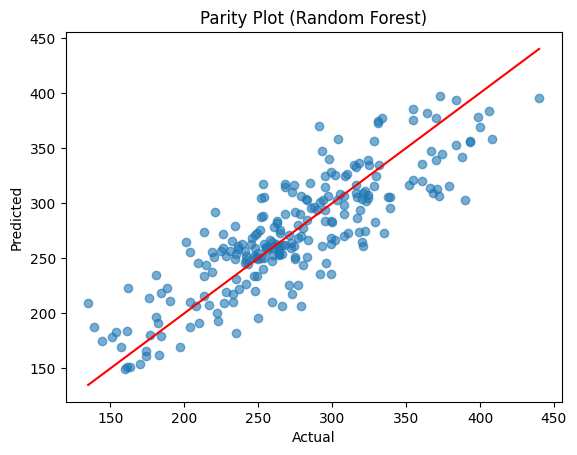

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Parity Plot (Random Forest)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

### Parity Plot Interpretation

The parity plot compares actual items_sold values with predicted values. Points closer to the diagonal line indicate better predictions. If the points are widely scattered away from the line, the model has higher prediction error. This plot helps visually assess how well the model’s predictions match actual sales.

In [12]:
ohe = preprocessor.named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(ohe_features) + numerical_cols

rf_model = rf_pipeline.named_steps['model']

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(5)

,feature,importance
15,is_festival,0.173533
10,store_size_small,0.167945
7,location_type_urban,0.108974
13,day_of_week,0.083833
14,is_weekend,0.071024


### Feature Importance Interpretation

The Random Forest feature importance output identifies the top factors influencing items_sold. Features with higher importance values contribute more to the model’s predictions. The top five features should be reviewed to understand which store, promotion, or time-based factors most strongly affect retail sales.